# BANKING77 text exploration

Customer-service intent classification. Source: [PolyAI](https://huggingface.co/datasets/PolyAI/banking77), CC BY 4.0; Casanueva et al. (2020). Inspect development data for modeling decisions; keep official test for final evaluation.

In [1]:
from support_ticket.eda import run
from support_ticket.data import load_prepared
from support_ticket.config import REPORTS
import pandas as pd
from IPython.display import display, Image
summary = run()
frames, labels = load_prepared()
summary

{'train': {'shape': [10003, 2], 'missing': {'text': 0, 'label': 0}, 'exact_duplicates': 0, 'normalized_text_duplicates': 4, 'classes': 77, 'words': {'count': 10003.0, 'mean': 11.949415175447365, 'std': 7.8915768393189625, 'min': 2.0, '25%': 7.0, '50%': 10.0, '75%': 13.0, 'max': 79.0}, 'under_3_words': 6, 'over_100_words': 0}, 'test': {'shape': [3080, 2], 'missing': {'text': 0, 'label': 0}, 'exact_duplicates': 0, 'normalized_text_duplicates': 1, 'classes': 77, 'words': {'count': 3080.0, 'mean': 10.952597402597403, 'std': 6.688180381157935, 'min': 2.0, '25%': 7.0, '50%': 9.0, '75%': 12.0, 'max': 69.0}, 'under_3_words': 3, 'over_100_words': 0}, 'train_test_text_overlap': 7}


{'train': {'shape': [10003, 2],
  'missing': {'text': 0, 'label': 0},
  'exact_duplicates': 0,
  'normalized_text_duplicates': 4,
  'classes': 77,
  'words': {'count': 10003.0,
   'mean': 11.949415175447365,
   'std': 7.8915768393189625,
   'min': 2.0,
   '25%': 7.0,
   '50%': 10.0,
   '75%': 13.0,
   'max': 79.0},
  'under_3_words': 6,
  'over_100_words': 0},
 'test': {'shape': [3080, 2],
  'missing': {'text': 0, 'label': 0},
  'exact_duplicates': 0,
  'normalized_text_duplicates': 1,
  'classes': 77,
  'words': {'count': 3080.0,
   'mean': 10.952597402597403,
   'std': 6.688180381157935,
   'min': 2.0,
   '25%': 7.0,
   '50%': 9.0,
   '75%': 12.0,
   'max': 69.0},
  'under_3_words': 3,
  'over_100_words': 0},
 'train_test_text_overlap': 7}

In [2]:
pd.read_csv(REPORTS / 'class_distribution.csv', index_col=0).describe()

,train,validation,test
count,77.000000,77.000000,77.0
mean,110.298701,19.467532,40.0
std,28.144395,4.943322,0.0
min,30.000000,5.000000,40.0
25%,94.000000,17.000000,40.0
50%,108.000000,19.000000,40.0
75%,135.000000,24.000000,40.0
max,159.000000,28.000000,40.0


In [3]:
display(frames['train'][['text', 'label']].sample(8, random_state=42))
lengths = frames['train'].text.str.split().str.len()
display(frames['train'].loc[lengths.nsmallest(3).index, ['text', 'label']])
display(frames['train'].loc[lengths.nlargest(3).index, ['text', 'label']])

,text,label
8219,"My top up hasn't gone through yet, why?",pending_top_up
4977,I tried taking out 30 pounds from the ATM just...,wrong_amount_of_cash_received
1535,Can my daughter make an account?,age_limit
5046,How much are you going to charge me if I top u...,top_up_by_card_charge
7445,Can I add a card that I just found (again) to ...,card_linking
5587,Why does my identity need verification?,why_verify_identity
3792,I need a new card to replace an expired one. W...,card_about_to_expire
7318,My card is missing! Help!,lost_or_stolen_card


,text,label
168,Cancel Transaction,cancel_transfer
1211,passcode retrieval,passcode_forgotten
1514,pending transaction?,pending_card_payment


,text,label
6040,Hearing back from us regarding your important ...,unable_to_verify_identity
4817,Hi! I'm a university student studying abroad a...,transfer_fee_charged
3338,It can take between 10 minutes to an hour befo...,unable_to_verify_identity


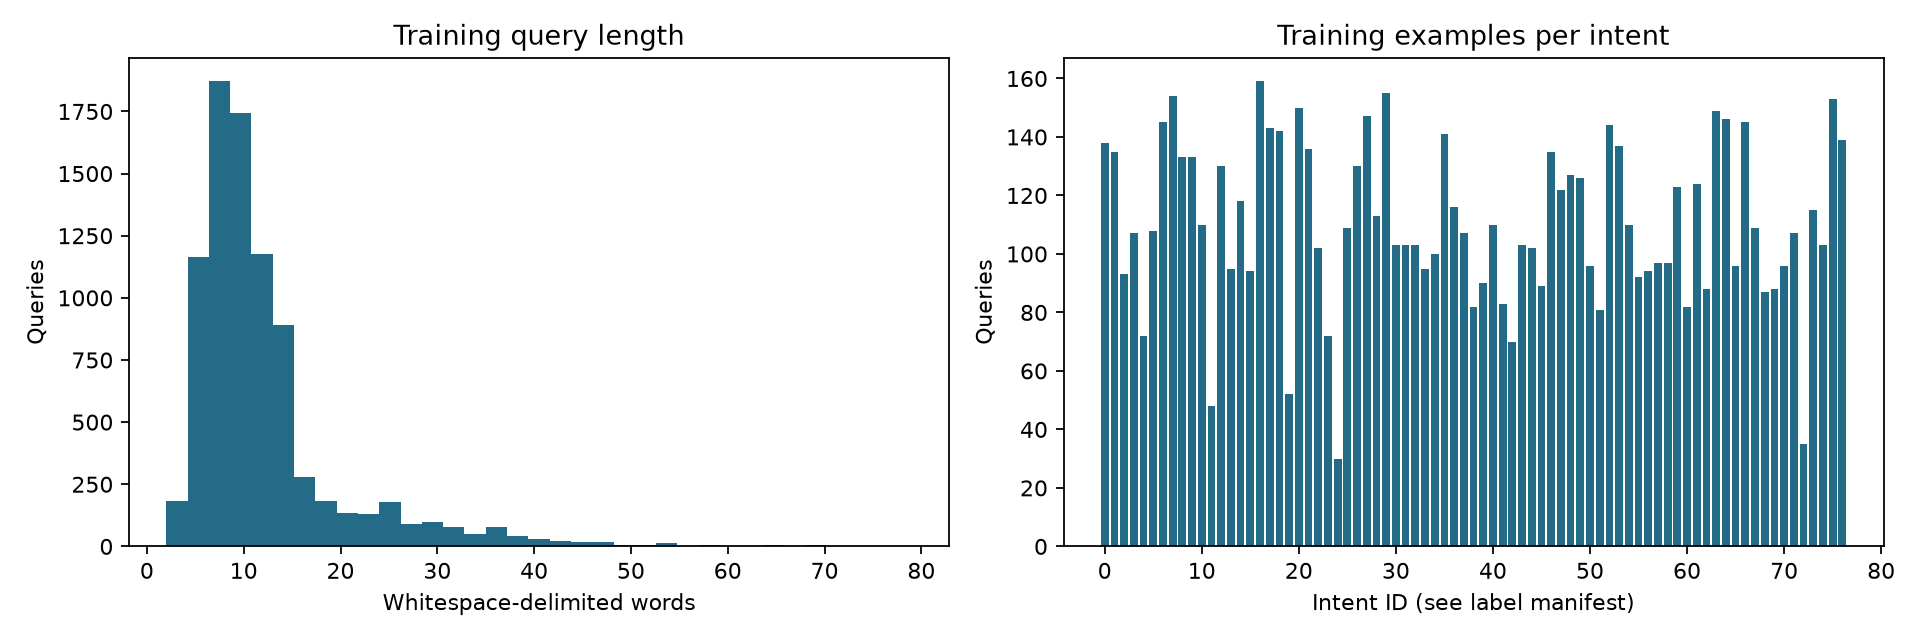

In [4]:
display(Image(filename=str(REPORTS / 'figures' / 'text_eda.png')))

## Interpretation

Queries are short, but lengths vary. Training supports vary by intent; the official test has 40 queries per intent. Macro F1 makes class-level weaknesses visible even when headline accuracy is strong. Normalized duplicates and train/test overlaps are handled before splitting. Exact deduplication does not eliminate paraphrase leakage. Full-length helpdesk conversations and non-banking requests remain outside this benchmark's scope.